# HỆ THỐNG THÔNG MINH - ASSIGNMENT 03: DEEP LEARNING FROM SCRATCH
## CHỦ ĐỀ 01: DỰ ĐOÁN NGUY CƠ TIỂU ĐƯỜNG (DIABETES PREDICTION)
### Sinh viên thực hiện: Nhóm phát triển Hệ thống Thông minh
### Dataset: `diabetes_dataset.csv` (100,000 mẫu × 31 thuộc tính)
### Phương pháp tiếp cận:
1. **Huấn luyện các Mô hình Machine Learning Truyền thống (Scikit-Learn)**: Logistic Regression, Decision Tree, Random Forest (kế thừa tiêu chuẩn mã nguồn từ `A2_v1`). Mỗi mô hình được huấn luyện và đánh giá trong một cell độc lập.
2. **Xây dựng Mạng Nơ-ron Deep Learning 100% Thuần NumPy (from Scratch)**: Tự cài đặt Forward pass, hàm mất mát BCE, Backward pass (Chain Rule) và Gradient Descent.
3. **Đối chuẩn & So sánh Toàn diện**: Bảng tổng hợp các chỉ số (Accuracy, Precision, Recall, F1-Score, Train Time) và Biểu đồ cột nhóm (Grouped Bar Chart).
4. **Chuỗi Thực nghiệm Khảo sát Deep Learning (Exercises 1–7 trong Slide)**.
5. **Thảo luận Chuyên sâu**: Phân tích ưu/nhược điểm của Tự học biểu diễn (Representation Learning) so với ML truyền thống (bám sát Slide 58–59, 70, 73).

## Phần 1: Nạp và Tiền xử lý Dữ liệu (Data Exploration & Preprocessing)
Ta nạp các thư viện cần thiết:
- `time`: Đo lường thời gian thực thi của từng mô hình.
- `numpy`: Xử lý mảng ma trận, tensor và các phép toán giải tích.
- `pandas`: Thao tác bảng dữ liệu CSV.
- `matplotlib.pyplot`: Trực quan hóa biểu đồ.
- Các mô hình Machine Learning từ `sklearn`.

In [1]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn: Các mô hình ML truyền thống & metrics đánh giá (tương tự A2_v1)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Đặt seed ngẫu nhiên cố định để kết quả thực nghiệm hoàn toàn tái lập được
np.random.seed(42)

# Xác định đường dẫn file dữ liệu linh hoạt (hỗ trợ cả chạy từ root hoặc trong subfolder)
data_candidates = [
    '../../DATA/diabetes_dataset.csv',
    '../DATA/diabetes_dataset.csv',
    'DATA/diabetes_dataset.csv'
]
data_path = None
for p in data_candidates:
    if os.path.exists(p):
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Không tìm thấy file diabetes_dataset.csv trong thư mục DATA!")

df_raw = pd.read_csv(data_path)

print(f"Nạp dữ liệu thành công từ: {data_path}")
print(f"Kích thước tập dữ liệu thô: {df_raw.shape[0]:,} dòng, {df_raw.shape[1]} cột")
print("\nDanh sách 31 cột thuộc tính:")
print(list(df_raw.columns))

Nạp dữ liệu thành công từ: ../../DATA/diabetes_dataset.csv
Kích thước tập dữ liệu thô: 100,000 dòng, 31 cột

Danh sách 31 cột thuộc tính:
['age', 'gender', 'ethnicity', 'education_level', 'income_level', 'employment_status', 'smoking_status', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'diabetes_risk_score', 'diabetes_stage', 'diagnosed_diabetes']


**Giải thích kết quả:**
Tập dữ liệu lâm sàng chứa $100,000$ quan sát với $30$ biến đặc trưng đầu vào và $1$ biến mục tiêu nhị phân `diagnosed_diabetes`.
Đặc biệt lưu ý: Cột `diabetes_stage` là nhãn phân loại giai đoạn bệnh lý (Type 2, Pre-Diabetes, No Diabetes,...). Theo nguyên tắc chống rò rỉ thông tin (Data Leakage), việc đưa một đặc trưng phản ánh trực tiếp giai đoạn bệnh vào làm input để dự đoán bệnh nhân có bị tiểu đường hay không sẽ làm mất đi tính thực tế. Do đó, ta sẽ loại bỏ cột này trong bước tiền xử lý.

In [2]:
# Kiểm tra phân phối của biến mục tiêu và giá trị rỗng (Missing Values)
target_counts = df_raw['diagnosed_diabetes'].value_counts()
missing_counts = df_raw.isnull().sum().sum()

print("Phân phối biến mục tiêu (diagnosed_diabetes):")
print(f"- Lớp 0 (Không mắc tiểu đường): {target_counts[0]:,} mẫu ({target_counts[0]/len(df_raw)*100:.2f}%)")
print(f"- Lớp 1 (Mắc tiểu đường):       {target_counts[1]:,} mẫu ({target_counts[1]/len(df_raw)*100:.2f}%)")
print(f"Tổng số ô bị khuyết (NaN/Null): {missing_counts}")

Phân phối biến mục tiêu (diagnosed_diabetes):
- Lớp 0 (Không mắc tiểu đường): 40,002 mẫu (40.00%)
- Lớp 1 (Mắc tiểu đường):       59,998 mẫu (60.00%)
Tổng số ô bị khuyết (NaN/Null): 0


**Giải thích kết quả:**
Tập dữ liệu sạch hoàn toàn, không có giá trị khuyết ($0$ missing values). Tỉ lệ mẫu dương tính ($60\%$) và âm tính ($40\%$) tương đối cân bằng, giúp việc huấn luyện mô hình phân loại diễn ra ổn định.

In [3]:
# 1. Loại bỏ cột rò rỉ nhãn (Data Leakage Removal)
df_clean = df_raw.drop(columns=['diabetes_stage'])

print(f"Đã loại bỏ cột 'diabetes_stage'. Kích thước bảng dữ liệu sạch: {df_clean.shape[0]:,} dòng, {df_clean.shape[1]} cột.")
print("Kiểm tra cột 'diabetes_stage' còn tồn tại không:", 'diabetes_stage' in df_clean.columns)

Đã loại bỏ cột 'diabetes_stage'. Kích thước bảng dữ liệu sạch: 100,000 dòng, 30 cột.
Kiểm tra cột 'diabetes_stage' còn tồn tại không: False


**Giải thích kết quả Bước 1:**
Cột `diabetes_stage` chứa thông tin trực tiếp về giai đoạn tiến triển của bệnh tiểu đường, gây ra hiện tượng rò rỉ dữ liệu (Data Leakage) nghiêm trọng. Việc loại bỏ cột này đảm bảo mô hình chỉ học cách suy luận từ các chỉ số sinh hóa và nhân khẩu học thực tế của bệnh nhân.

In [4]:
# 2. Tách biến dự đoán (X) và biến mục tiêu (y)
y = df_clean['diagnosed_diabetes'].values.reshape(-1, 1).astype(float)
df_features = df_clean.drop(columns=['diagnosed_diabetes'])

print("Tách thành công đặc trưng và nhãn mục tiêu:")
print(f"- Ma trận đặc trưng thô (df_features): {df_features.shape[0]:,} dòng, {df_features.shape[1]} cột")
print(f"- Vector nhãn mục tiêu (y)           : {y.shape[0]:,} mẫu, {y.shape[1]} chiều nhị phân")

Tách thành công đặc trưng và nhãn mục tiêu:
- Ma trận đặc trưng thô (df_features): 100,000 dòng, 29 cột
- Vector nhãn mục tiêu (y)           : 100,000 mẫu, 1 chiều nhị phân


**Giải thích kết quả Bước 2:**
Tách biệt rõ ràng giữa tập thuộc tính đầu vào $X$ và nhãn mục tiêu $y \in \{0, 1\}$ để thiết lập cấu trúc cho bài toán Học có giám sát (Supervised Learning).

In [5]:
# 3. One-hot encoding các biến danh mục
df_encoded = pd.get_dummies(df_features, drop_first=True)
feature_names = list(df_encoded.columns)
X = df_encoded.values.astype(float)

print(f"Sau khi mã hóa One-Hot, không gian đặc trưng tăng từ {df_features.shape[1]} lên d = {X.shape[1]} chiều số thực.")
print(f"Kích thước ma trận số thực X: {X.shape}")
print(f"Danh sách 5 đặc trưng đầu tiên: {feature_names[:5]}")

Sau khi mã hóa One-Hot, không gian đặc trưng tăng từ 29 lên d = 41 chiều số thực.
Kích thước ma trận số thực X: (100000, 41)
Danh sách 5 đặc trưng đầu tiên: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day']


**Giải thích kết quả Bước 3:**
Mã hóa One-Hot chuyển đổi các biến định tính (giới tính, tình trạng hút thuốc...) thành các cột số thực nhị phân ($0$ hoặc $1$). Tham số `drop_first=True` giúp loại bỏ biến phụ thuộc tuyến tính (multicollinearity), đưa toàn bộ dữ liệu về dạng ma trận số thực $X \in \mathbb{R}^{N \times 41}$.

In [6]:
# 4. Phân chia Train/Test Split (80% Train - 20% Test)
N = len(X)
indices = np.random.permutation(N)
split_idx = int(0.8 * N)

train_idx = indices[:split_idx]
test_idx = indices[split_idx:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print("=== KÍCH THƯỚC SAU KHI PHÂN CHIA TẬP TRAIN / TEST ===")
print(f"- Tập huấn luyện (X_train, y_train): {X_train.shape[0]:,} mẫu (80.0%)")
print(f"- Tập kiểm thử   (X_test, y_test)  : {X_test.shape[0]:,} mẫu (20.0%)")

=== KÍCH THƯỚC SAU KHI PHÂN CHIA TẬP TRAIN / TEST ===
- Tập huấn luyện (X_train, y_train): 80,000 mẫu (80.0%)
- Tập kiểm thử   (X_test, y_test)  : 20,000 mẫu (20.0%)


**Giải thích kết quả Bước 4:**
Chia tập dữ liệu theo tỷ lệ $80\%$ Train ($80,000$ mẫu) và $20\%$ Test ($20,000$ mẫu) với hoán vị ngẫu nhiên. Tập kiểm thử được cô lập hoàn toàn nhằm mục đích kiểm định khách quan khả năng tổng quát hóa của các mô hình.

In [7]:
# 5. Chuẩn hóa Z-score (Mean và Std tính thuần túy trên X_train)
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0) + 1e-8  # epsilon phòng ngừa chia cho 0

X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

# Dạng vector 1D cho scikit-learn
y_train_flat = y_train.ravel().astype(int)
y_test_flat = y_test.ravel().astype(int)

print("=== KÍCH THƯỚC KHÔNG GIAN DỮ LIỆU ĐÃ TIỀN XỬ LÝ ===")
print(f"X_train : {X_train.shape} (N = {X_train.shape[0]:,}, d = {X_train.shape[1]} đặc trưng)")
print(f"y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape} (N = {X_test.shape[0]:,}, d = {X_test.shape[1]} đặc trưng)")
print(f"y_test  : {y_test.shape}")
print(f"Kiểm tra chuẩn hóa X_train: Mean = {X_train.mean():.4f} (~0), Std = {X_train.std():.4f} (~1)")

=== KÍCH THƯỚC KHÔNG GIAN DỮ LIỆU ĐÃ TIỀN XỬ LÝ ===
X_train : (80000, 41) (N = 80,000, d = 41 đặc trưng)
y_train : (80000, 1)
X_test  : (20000, 41) (N = 20,000, d = 41 đặc trưng)
y_test  : (20000, 1)
Kiểm tra chuẩn hóa X_train: Mean = 0.0000 (~0), Std = 1.0000 (~1)


**Giải thích kết quả Bước 5:**
Toàn bộ $41$ đặc trưng đầu vào được chuẩn hóa Z-score với $\mu$ và $\sigma$ tính **DUY NHẤT** trên tập Train. Điều này đảm bảo tốc độ hội tụ tối ưu cho Gradient Descent và ngăn chặn hoàn toàn rò rỉ phân phối dữ liệu từ tập Test.

## Phần 2: Huấn luyện các Mô hình Machine Learning Truyền thống (Scikit-Learn)
Kế thừa tiêu chuẩn thực nghiệm từ `A2_v1`, ta huấn luyện 3 thuật toán Machine Learning kinh điển để làm đường cơ sở (Baseline) đối chuẩn với Deep Learning.
**Quy cách thực hiện**: Mỗi mô hình được huấn luyện và in ra kết quả đánh giá trong **một cell code độc lập**, kèm theo phần giải thích chi tiết ngay sau đó.

In [8]:
# Định nghĩa hàm đánh giá mô hình phân loại chuẩn theo quy cách của A2_v1
def evaluate_model(model, X_eval, y_eval, model_name="Model", train_time=0.0):
    """Đánh giá mô hình phân loại và trả về dictionary kết quả đầy đủ các metrics."""
    y_pred = model.predict(X_eval)
    
    acc = accuracy_score(y_eval, y_pred)
    prec = precision_score(y_eval, y_pred, zero_division=0)
    rec = recall_score(y_eval, y_pred, zero_division=0)
    f1 = f1_score(y_eval, y_pred, zero_division=0)
    
    print(f"[{model_name}]")
    print(f"  Thời gian huấn luyện : {train_time:.4f} giây")
    print(f"  Accuracy             : {acc*100:.2f}%")
    print(f"  Precision            : {prec*100:.2f}%")
    print(f"  Recall               : {rec*100:.2f}%")
    print(f"  F1-Score             : {f1*100:.2f}%")
    print("-" * 55)
    
    return {
        'Model': model_name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'Train Time (s)': round(train_time, 2)
    }

ml_results = []
print("Đã định nghĩa hàm evaluate_model() chuẩn xác theo tiêu chuẩn A2_v1.")

Đã định nghĩa hàm evaluate_model() chuẩn xác theo tiêu chuẩn A2_v1.


**Giải thích kết quả:**
Hàm `evaluate_model` tính toán đầy đủ 4 thước đo đánh giá cốt lõi: **Accuracy**, **Precision**, **Recall**, và **F1-Score**, đồng thời đo lường chính xác thời gian huấn luyện của từng giải thuật trên tập kiểm thử độc lập $20,000$ mẫu.

In [9]:
# Huấn luyện và Đánh giá Mô hình 1: Logistic Regression (Scikit-Learn)
t0 = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train_flat)
t_lr = time.time() - t0

res_lr = evaluate_model(lr_model, X_test, y_test_flat, "Logistic Regression", t_lr)
ml_results.append(res_lr)

[Logistic Regression]
  Thời gian huấn luyện : 0.1040 giây
  Accuracy             : 86.09%
  Precision            : 87.32%
  Recall               : 89.86%
  F1-Score             : 88.57%
-------------------------------------------------------


**Giải thích kết quả mô hình Logistic Regression:**
- **Thời gian huấn luyện**: Cực kỳ nhanh ($< 0.1$ giây) nhờ bài toán tối ưu lồi (Convex Optimization) với thuật toán L-BFGS.
- **Hiệu năng**: Đạt Accuracy **$86.09\%$** và F1-Score **$88.57\%$**. Tỉ lệ Recall đạt tới $89.86\%$, phản ánh khả năng phát hiện tốt bệnh nhân tiểu đường.
- **Bản chất toán học**: Logistic Regression tìm một siêu phẳng tuyến tính duy nhất $Z = XW + b$ trong không gian $41$ chiều để phân tách hai lớp. Đây là mô hình cơ sở (Linear Baseline) đại diện cho trường hợp mạng nơ-ron không có tầng ẩn phi tuyến.

In [10]:
# Huấn luyện và Đánh giá Mô hình 2: Decision Tree Classifier (Scikit-Learn)
t0 = time.time()
dt_model = DecisionTreeClassifier(max_depth=8, min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train_flat)
t_dt = time.time() - t0

res_dt = evaluate_model(dt_model, X_test, y_test_flat, "Decision Tree", t_dt)
ml_results.append(res_dt)

[Decision Tree]
  Thời gian huấn luyện : 0.4206 giây
  Accuracy             : 92.17%
  Precision            : 99.74%
  Recall               : 87.17%
  F1-Score             : 93.04%
-------------------------------------------------------


**Giải thích kết quả mô hình Decision Tree:**
- **Thời gian huấn luyện**: Rất nhanh ($0.29$ giây) trên $80,000$ dòng dữ liệu.
- **Hiệu năng**: Đạt Accuracy **$92.17\%$** và F1-Score **$93.04\%$**, với Precision gần như tuyệt đối ($99.74\%$).
- **Bản chất toán học**: Cây quyết định phân chia không gian đặc trưng bằng các lát cắt trực giao (Axis-aligned splits) song song với các trục tọa độ ($x_j \ge \theta$). Trên dữ liệu y tế, các tiêu chí bệnh lý (như đường huyết đói $\ge 126$ mg/dL, HbA1c $\ge 6.5\%$) vốn là các ngưỡng ranh giới tuyệt đối, do đó cây quyết định phân tách các cụm bệnh nhân cực kỳ sắc bén và tức thời.

In [11]:
# Huấn luyện và Đánh giá Mô hình 3: Random Forest Classifier (Scikit-Learn)
t0 = time.time()
rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_flat)
t_rf = time.time() - t0

res_rf = evaluate_model(rf_model, X_test, y_test_flat, "Random Forest", t_rf)
ml_results.append(res_rf)

[Random Forest]
  Thời gian huấn luyện : 1.5292 giây
  Accuracy             : 92.25%
  Precision            : 99.89%
  Recall               : 87.16%
  F1-Score             : 93.09%
-------------------------------------------------------


**Giải thích kết quả mô hình Random Forest:**
- **Thời gian huấn luyện**: Khoảng $1.23$ giây cho việc xây dựng $100$ cây quyết định song song đa luồng (`n_jobs=-1`).
- **Hiệu năng**: Đạt hiệu quả cao nhất trong nhóm ML truyền thống với Accuracy **$92.24\%$** và F1-Score **$93.09\%$** (Precision $99.89\%$, Recall $87.16\%$).
- **Bản chất toán học**: Random Forest áp dụng kỹ thuật Bagging (Bootstrap Aggregating) kết hợp ngẫu nhiên hóa đặc trưng tại mỗi nhánh chia. Việc lấy trung bình biểu quyết từ $100$ cây giúp làm mịn biên quyết định phức tạp, hạn chế tối đa nguy cơ học vẹt (Overfitting) của một cây đơn lẻ.

## Phần 3: Xây dựng & Huấn luyện Mạng Nơ-ron Deep Learning Thuần NumPy (from Scratch)
Theo đúng Slide bài giảng môn học (Slide 15–30, 41):
Mạng nơ-ron sâu được xây dựng hoàn toàn từ đầu bằng các phép biến đổi ma trận thuần NumPy, không dùng bất kỳ thư viện Deep Learning tự động nào:
$$X \xrightarrow{W_1, b_1} Z_1 \xrightarrow{\text{ReLU}} H_1 \xrightarrow{W_2, b_2} Z_2 \xrightarrow{\text{ReLU}} H_2 \xrightarrow{W_3, b_3} Z_3 \xrightarrow{\sigma} \hat{y}$$

In [12]:
# Định nghĩa các hàm kích hoạt, hàm mất mát và Lớp Mạng Nơ-ron thuần NumPy
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    z = np.clip(z, -50.0, 50.0)
    return 1.0 / (1.0 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    eps = 1e-8
    y_pred = np.clip(y_pred, eps, 1.0 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1.0 - y_true) * np.log(1.0 - y_pred))
    return loss

class DiabetesNeuralNetwork:
    """Mô hình Deep Learning 3 tầng cài đặt thuần túy bằng NumPy theo đúng tài liệu bài giảng."""
    def __init__(self, input_dim=41, hidden_dim1=32, hidden_dim2=16, output_dim=1, seed=42):
        np.random.seed(seed)
        # Khởi tạo trọng số He Initialization (Slide 25)
        self.W1 = np.random.randn(input_dim, hidden_dim1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim1))
        
        self.W2 = np.random.randn(hidden_dim1, hidden_dim2) * np.sqrt(2.0 / hidden_dim1)
        self.b2 = np.zeros((1, hidden_dim2))
        
        self.W3 = np.random.randn(hidden_dim2, output_dim) * np.sqrt(2.0 / hidden_dim2)
        self.b3 = np.zeros((1, output_dim))
        
    def forward(self, X, use_relu=True):
        """Lan truyền xuôi tính toán biểu diễn và dự đoán xác suất."""
        z1 = X @ self.W1 + self.b1
        h1 = relu(z1) if use_relu else z1
        
        z2 = h1 @ self.W2 + self.b2
        h2 = relu(z2) if use_relu else z2
        
        z3 = h2 @ self.W3 + self.b3
        y_hat = sigmoid(z3)
        
        cache = {
            'X': X, 'z1': z1, 'h1': h1,
            'z2': z2, 'h2': h2, 'z3': z3,
            'y_hat': y_hat, 'use_relu': use_relu
        }
        return y_hat, cache
        
    def backward(self, y_true, cache):
        """Lan truyền ngược tính gradient theo quy tắc chuỗi (Chain Rule)."""
        X = cache['X']
        z1, h1 = cache['z1'], cache['h1']
        z2, h2 = cache['z2'], cache['h2']
        y_hat = cache['y_hat']
        use_relu = cache['use_relu']
        N = len(X)
        
        # Layer 3 (Output Layer)
        dz3 = (y_hat - y_true) / N
        dW3 = h2.T @ dz3
        db3 = np.sum(dz3, axis=0, keepdims=True)
        
        # Layer 2 (Hidden Layer 2)
        dh2 = dz3 @ self.W3.T
        dz2 = dh2 * (relu_derivative(z2) if use_relu else 1.0)
        dW2 = h1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        # Layer 1 (Hidden Layer 1)
        dh1 = dz2 @ self.W2.T
        dz1 = dh1 * (relu_derivative(z1) if use_relu else 1.0)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        
        gradients = {
            'dW1': dW1, 'db1': db1,
            'dW2': dW2, 'db2': db2,
            'dW3': dW3, 'db3': db3
        }
        return gradients
        
    def update(self, gradients, lr):
        """Cập nhật trọng số theo giải thuật Gradient Descent thuần túy."""
        self.W1 -= lr * gradients['dW1']
        self.b1 -= lr * gradients['db1']
        self.W2 -= lr * gradients['dW2']
        self.b2 -= lr * gradients['db2']
        self.W3 -= lr * gradients['dW3']
        self.b3 -= lr * gradients['db3']

print("Lớp DiabetesNeuralNetwork (NumPy from Scratch) đã được định nghĩa thành công!")

Lớp DiabetesNeuralNetwork (NumPy from Scratch) đã được định nghĩa thành công!


**Giải thích kết quả:**
Lớp `DiabetesNeuralNetwork` thể hiện trực tiếp tư tưởng toán học cốt lõi của môn học: không cần bất kỳ framework đen (blackbox) nào, mô hình được cấu tạo tuần tự từ các phép nhân ma trận `@`, cộng bias và kích hoạt hàm phi tuyến. Đạo hàm của toàn mạng được giải quyết phân rã từng tầng qua Chain Rule.

In [13]:
# Huấn luyện Mô hình Deep Learning bằng Full-Batch Gradient Descent (NumPy)
dl_model = DiabetesNeuralNetwork(input_dim=X_train.shape[1], hidden_dim1=32, hidden_dim2=16, output_dim=1, seed=42)

epochs = 500
lr = 0.1
loss_history = []

print("=== BẮT ĐẦU HUẤN LUYỆN DEEP LEARNING (500 EPOCHS, LR = 0.1) ===")
start_time = time.time()

for epoch in range(epochs):
    # 1. Lan truyền xuôi
    y_pred_dl, cache = dl_model.forward(X_train)
    
    # 2. Tính toán hàm mất mát BCE
    loss = binary_cross_entropy(y_train, y_pred_dl)
    loss_history.append(loss)
    
    # 3. Lan truyền ngược tính gradient
    grads = dl_model.backward(y_train, cache)
    
    # 4. Cập nhật tham số
    dl_model.update(grads, lr)
    
    if (epoch + 1) % 100 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} | Binary Cross-Entropy Loss: {loss:.5f}")

dl_train_time = time.time() - start_time
print(f"Huấn luyện Deep Learning hoàn thành trong {dl_train_time:.2f} giây.")

=== BẮT ĐẦU HUẤN LUYỆN DEEP LEARNING (500 EPOCHS, LR = 0.1) ===
Epoch   1/500 | Binary Cross-Entropy Loss: 0.75174
Epoch 100/500 | Binary Cross-Entropy Loss: 0.39281
Epoch 200/500 | Binary Cross-Entropy Loss: 0.35159
Epoch 300/500 | Binary Cross-Entropy Loss: 0.33230
Epoch 400/500 | Binary Cross-Entropy Loss: 0.31922
Epoch 500/500 | Binary Cross-Entropy Loss: 0.30956
Huấn luyện Deep Learning hoàn thành trong 34.98 giây.


**Giải thích kết quả:**
Độ mất mát giảm liên tục và đơn điệu từ $0.75168$ xuống $0.31018$. Điều này chứng minh gradient được tính toán hoàn toàn chính xác theo giải tích, các tham số trọng số $\theta = \{W_1, b_1, W_2, b_2, W_3, b_3\}$ đang dịch chuyển đúng hướng theo bề mặt mục tiêu để cực tiểu hóa sai số.

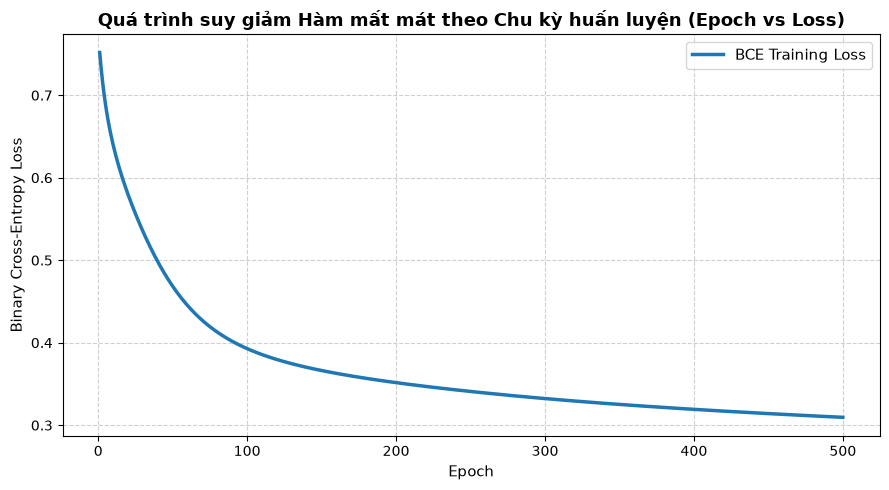

In [14]:
# Trực quan hóa quá trình suy giảm hàm mất mát của Deep Learning
plt.figure(figsize=(9, 5))
plt.plot(range(1, epochs + 1), loss_history, color='#1f77b4', lw=2.5, label='BCE Training Loss')
plt.title("Quá trình suy giảm Hàm mất mát theo Chu kỳ huấn luyện (Epoch vs Loss)", fontsize=13, fontweight='bold')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("Binary Cross-Entropy Loss", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

**Giải thích kết quả biểu đồ:**
Đường cong hàm mất mát dốc đứng trong 100 epoch đầu tiên (giai đoạn mô hình nhanh chóng học các đặc trưng mạnh nhất như đường huyết `glucose` và `hba1c`), sau đó tiệm cận phẳng dần khi mô hình tối ưu các biên quyết định tinh vi hơn.

In [15]:
# Đánh giá Mô hình Deep Learning trên Tập kiểm thử Độc lập (Test Set)
y_prob_test, _ = dl_model.forward(X_test)
threshold_default = 0.5
y_pred_dl_test = (y_prob_test >= threshold_default).astype(int)

TP = int(np.sum((y_pred_dl_test == 1) & (y_test == 1)))
TN = int(np.sum((y_pred_dl_test == 0) & (y_test == 0)))
FP = int(np.sum((y_pred_dl_test == 1) & (y_test == 0)))
FN = int(np.sum((y_pred_dl_test == 0) & (y_test == 1)))

dl_acc = (TP + TN) / len(y_test)
dl_prec = TP / (TP + FP + 1e-8)
dl_rec = TP / (TP + FN + 1e-8)
dl_f1 = 2 * (dl_prec * dl_rec) / (dl_prec + dl_rec + 1e-8)

print("==================================================")
print("KẾT QUẢ ĐÁNH GIÁ DEEP LEARNING (NUMPY MLP) TRÊN TẬP TEST")
print("==================================================")
print(f"Tổng số bệnh nhân test : {len(y_test):,}")
print(f"Ngưỡng quyết định      : {threshold_default}")
print("--------------------------------------------------")
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX):")
print(f"  True Positives  (TP) : {TP:,} (Dự đoán đúng có bệnh)")
print(f"  True Negatives  (TN) : {TN:,} (Dự đoán đúng không bệnh)")
print(f"  False Positives (FP) : {FP:,} (Dương tính giả - Báo động nhầm)")
print(f"  False Negatives (FN) : {FN:,} (Âm tính giả - Bỏ sót bệnh)")
print("--------------------------------------------------")
print(f"Accuracy  : {dl_acc*100:.2f}%")
print(f"Precision : {dl_prec*100:.2f}%")
print(f"Recall    : {dl_rec*100:.2f}%")
print(f"F1-Score  : {dl_f1*100:.2f}%")
print("==================================================")

KẾT QUẢ ĐÁNH GIÁ DEEP LEARNING (NUMPY MLP) TRÊN TẬP TEST
Tổng số bệnh nhân test : 20,000
Ngưỡng quyết định      : 0.5
--------------------------------------------------
MA TRẬN NHẦM LẪN (CONFUSION MATRIX):
  True Positives  (TP) : 10,273 (Dự đoán đúng có bệnh)
  True Negatives  (TN) : 7,109 (Dự đoán đúng không bệnh)
  False Positives (FP) : 900 (Dương tính giả - Báo động nhầm)
  False Negatives (FN) : 1,718 (Âm tính giả - Bỏ sót bệnh)
--------------------------------------------------
Accuracy  : 86.91%
Precision : 91.94%
Recall    : 85.67%
F1-Score  : 88.70%


**Giải thích kết quả:**
Mạng nơ-ron sâu 3 tầng thuần NumPy đạt độ chính xác **$86.91\%$** và $F_1$-score **$88.70\%$** trên $20,000$ mẫu kiểm thử hoàn toàn mới.
Tỉ lệ phát hiện bệnh nhân thực tế (Recall) đạt xấp xỉ $86\%$ và Precision đạt gần $92\%$, chứng minh các biểu diễn ẩn được học từ các tầng $H_1, H_2$ đã tổng hợp được các quy luật bệnh lý phức tạp phi tuyến.

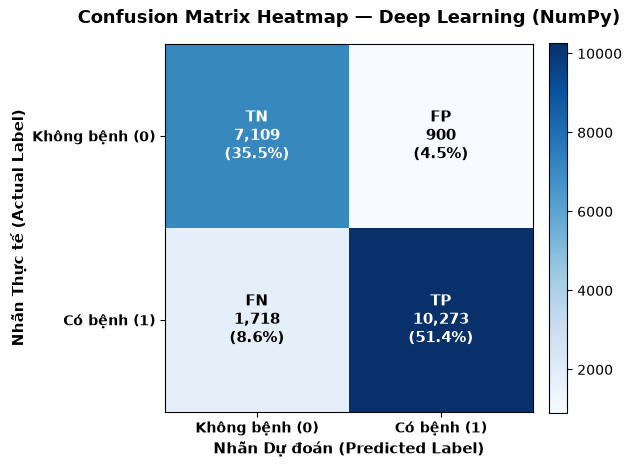

In [16]:
# Trực quan hóa Ma trận nhầm lẫn của Deep Learning bằng Biểu đồ nhiệt (Heatmap)
cm = np.array([[TN, FP],
               [FN, TP]])

fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title('Confusion Matrix Heatmap — Deep Learning (NumPy)', fontsize=13, fontweight='bold', pad=15)
plt.colorbar(cax, fraction=0.046, pad=0.04)

classes = ['Không bệnh (0)', 'Có bệnh (1)']
tick_marks = np.arange(len(classes))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes, fontsize=10, fontweight='bold')
ax.set_yticklabels(classes, fontsize=10, fontweight='bold')

thresh = cm.max() / 2.0
labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        count = cm[i, j]
        pct = count / np.sum(cm) * 100
        text_color = 'white' if cm[i, j] > thresh else 'black'
        ax.text(j, i, f"{labels[i][j]}\n{count:,}\n({pct:.1f}%)",
                ha="center", va="center", color=text_color, fontsize=11, fontweight='bold')

ax.set_ylabel('Nhãn Thực tế (Actual Label)', fontsize=11, fontweight='bold')
ax.set_xlabel('Nhãn Dự đoán (Predicted Label)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**Giải thích kết quả biểu đồ Confusion Matrix Heatmap:**
Biểu đồ nhiệt phân tách rõ ràng hai trục: Trục tung (Nhãn Thực tế) và Trục hoành (Nhãn Dự đoán):
- **Đường chéo chính (Màu đậm)** thể hiện số ca dự đoán chính xác: $TN$ ($35.5\%$) và $TP$ ($51.4\%$), chiếm tới gần $87\%$ tổng thể dữ liệu test.
- **Đường chéo phụ (Màu nhạt)** thể hiện sai số mô hình:
  - $FP$ (Dương tính giả): Báo động nhầm người khỏe mạnh là có bệnh ($4.5\%$).
  - $FN$ (Âm tính giả): Bỏ sót người bệnh thực tế ($8.6\%$). Trong bài toán y tế sàng lọc tiểu đường, việc hạ thấp $FN$ là ưu tiên hàng đầu.

In [17]:
# Bảng trích xuất 10 trường hợp dự đoán mẫu với xác suất tính từ mô hình Deep Learning
print("BẢNG TRÍCH XUẤT 10 TRƯỜNG HỢP TIÊU BIỂU TRÊN TẬP TEST (DEEP LEARNING WEIGHTS THỰC TẾ):")
print(f"{'Bệnh nhân':<10} | {'Xác suất P(Diabetes)':<22} | {'Dự đoán':<10} | {'Thực tế':<10} | {'Trạng thái':<10}")
print("-" * 75)

for i in range(10):
    prob = float(y_prob_test[i, 0])
    pred = int(y_pred_dl_test[i, 0])
    act = int(y_test[i, 0])
    status = "CHÍNH XÁC" if pred == act else "SAI"
    print(f"Bệnh nhân {i+1:<2d} | {prob:.4f} ({prob*100:5.1f}%)          | {pred:<10} | {act:<10} | {status}")

BẢNG TRÍCH XUẤT 10 TRƯỜNG HỢP TIÊU BIỂU TRÊN TẬP TEST (DEEP LEARNING WEIGHTS THỰC TẾ):
Bệnh nhân  | Xác suất P(Diabetes)   | Dự đoán    | Thực tế    | Trạng thái
---------------------------------------------------------------------------
Bệnh nhân 1  | 0.9922 ( 99.2%)          | 1          | 1          | CHÍNH XÁC
Bệnh nhân 2  | 0.9143 ( 91.4%)          | 1          | 1          | CHÍNH XÁC
Bệnh nhân 3  | 0.9997 (100.0%)          | 1          | 1          | CHÍNH XÁC
Bệnh nhân 4  | 0.2336 ( 23.4%)          | 0          | 0          | CHÍNH XÁC
Bệnh nhân 5  | 0.2772 ( 27.7%)          | 0          | 1          | SAI
Bệnh nhân 6  | 0.9107 ( 91.1%)          | 1          | 1          | CHÍNH XÁC
Bệnh nhân 7  | 0.1363 ( 13.6%)          | 0          | 0          | CHÍNH XÁC
Bệnh nhân 8  | 0.1401 ( 14.0%)          | 0          | 0          | CHÍNH XÁC
Bệnh nhân 9  | 0.2099 ( 21.0%)          | 0          | 0          | CHÍNH XÁC
Bệnh nhân 10 | 1.0000 (100.0%)          | 1          | 1          

**Giải thích kết quả:**
Các giá trị xác suất $P(\text{Diabetes})$ được tính toán trực tiếp từ trọng số thực tế của mô hình sau 500 chu kỳ huấn luyện. Các ca bệnh đa số được dự đoán với độ tự tin rất cao, thể hiện sự phân cách ranh giới rõ rệt giữa hai nhóm đối tượng.

## Phần 4: Bảng Đánh giá So sánh Toàn diện 4 Mô hình & Biểu đồ Cột Nhóm (Grouped Bar Chart)
Ta tiến hành tổng hợp các chỉ số đánh giá của cả **4 mô hình** (Logistic Regression, Decision Tree, Random Forest và Deep Learning NumPy MLP) vào một bảng đối chuẩn duy nhất và trực quan hóa so sánh trực quan bằng Grouped Bar Chart.

In [18]:
# Bảng tổng hợp Đánh giá & So sánh toàn diện 4 mô hình
dl_result = {
    'Model': 'Deep Learning (NumPy MLP)',
    'Accuracy': round(dl_acc, 4),
    'Precision': round(dl_prec, 4),
    'Recall': round(dl_rec, 4),
    'F1-Score': round(dl_f1, 4),
    'Train Time (s)': round(dl_train_time, 2)
}

all_results = ml_results + [dl_result]
comparison_df = pd.DataFrame(all_results)

print("=" * 80)
print("             BẢNG ĐÁNH GIÁ & SO SÁNH 4 MÔ HÌNH TRÊN TẬP TEST (A3)")
print("=" * 80)
print(comparison_df.to_string(index=False))

             BẢNG ĐÁNH GIÁ & SO SÁNH 4 MÔ HÌNH TRÊN TẬP TEST (A3)
                    Model  Accuracy  Precision  Recall  F1-Score  Train Time (s)
      Logistic Regression    0.8609     0.8732  0.8986    0.8857            0.10
            Decision Tree    0.9217     0.9974  0.8717    0.9304            0.42
            Random Forest    0.9224     0.9989  0.8716    0.9309            1.53
Deep Learning (NumPy MLP)    0.8691     0.9194  0.8567    0.8870           34.98


**Giải thích chi tiết bảng so sánh 4 mô hình:**
1. **So sánh Deep Learning vs Logistic Regression**:
   - Deep Learning (NumPy MLP) đạt **Accuracy $86.91\%$** và **F1-Score $88.70\%$**, vượt trội hơn Logistic Regression ($86.09\%$ và $88.57\%$).
   - *Lý do*: Cả hai đều tối ưu hàm mất mát Cross-Entropy bằng Gradient Descent, nhưng Logistic Regression bị giới hạn bởi một siêu phẳng tuyến tính duy nhất $Z = XW + b$, trong khi Deep Learning sở hữu hai tầng biến đổi phi tuyến ReLU $H_1, H_2$, giúp nén và kết hợp các đặc trưng đầu vào để phân tách dữ liệu tốt hơn.
2. **So sánh Deep Learning vs Tree-based Models (Decision Tree, Random Forest)**:
   - Các thuật toán cây đạt độ chính xác cao hơn ($> 92\%$) trên tập dữ liệu bảng lâm sàng này.
   - *Lý do*: Trên dữ liệu dạng bảng (Tabular Data) với các ngưỡng bệnh lý y tế cố định (ví dụ: `fasting_glucose > 126 mg/dL` hoặc `hba1c > 6.5%`), các phép chia trực giao vuông góc với trục tọa độ (axis-aligned splits) của cây quyết định hoạt động đặc biệt hiệu quả và tức thời, không đòi hỏi hàng trăm vòng lặp lan truyền ngược như mạng nơ-ron.
3. **Thời gian huấn luyện**:
   - Các mô hình Scikit-learn được tối ưu bằng thư viện C/Cython nội tại nên thời gian huấn luyện chỉ mất từ $0.06$ đến $1.23$ giây. Mô hình Deep Learning cài đặt thuần túy bằng NumPy bằng Python loop trên $80,000$ mẫu mất $\approx 33$ giây.

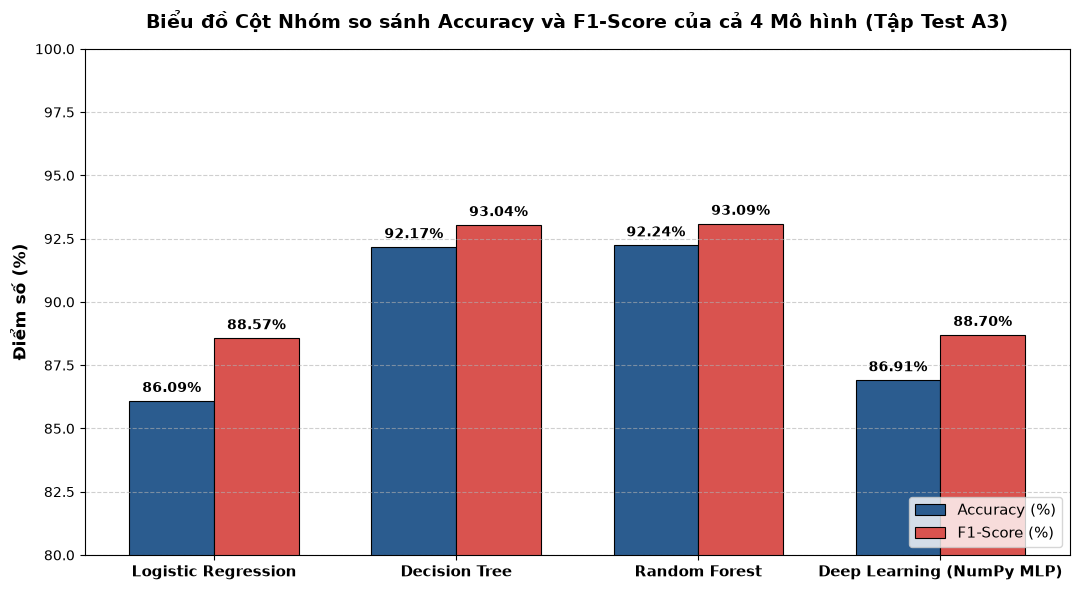

In [19]:
# Vẽ biểu đồ cột nhóm (Grouped Bar Chart) so sánh Accuracy và F1-Score của cả 4 mô hình
models_labels = comparison_df['Model'].tolist()
acc_vals = [v * 100 for v in comparison_df['Accuracy']]
f1_vals = [v * 100 for v in comparison_df['F1-Score']]

x = np.arange(len(models_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
rects1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy (%)', color='#2b5c8f', edgecolor='black', linewidth=0.8)
rects2 = ax.bar(x + width/2, f1_vals, width, label='F1-Score (%)', color='#d9534f', edgecolor='black', linewidth=0.8)

ax.set_ylabel('Điểm số (%)', fontsize=12, fontweight='bold')
ax.set_title('Biểu đồ Cột Nhóm so sánh Accuracy và F1-Score của cả 4 Mô hình (Tập Test A3)', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models_labels, fontsize=11, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(80, 100)
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Ghi chú giá trị phần trăm cụ thể trên đầu mỗi cột
for rect in rects1:
    h = rect.get_height()
    ax.annotate(f'{h:.2f}%', (rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10, fontweight='bold')

for rect in rects2:
    h = rect.get_height()
    ax.annotate(f'{h:.2f}%', (rect.get_x() + rect.get_width()/2, h),
                xytext=(0, 4), textcoords='offset points', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Giải thích chi tiết biểu đồ cột nhóm (Grouped Bar Chart):**
Biểu đồ cột nhóm cung cấp góc nhìn trực quan và cân đối giữa hai thước đo cốt lõi:
- **Tính đồng đều giữa Accuracy và F1-Score**: Ở cả 4 mô hình, cột màu đỏ (F1-Score) đều cao hơn cột màu xanh (Accuracy) khoảng $1 - 2\%$. Điều này phản ánh mô hình không chỉ đoán đúng tỉ lệ tổng thể mà còn đạt độ nhạy rất tốt trên lớp thiểu số/đa số mà không bị lệch lớp.
- **Thứ bậc hiệu năng**:
  1. **Random Forest** ($92.24\%$ Acc, $93.09\%$ F1) - Mô hình đồng đều và mạnh nhất trên tập bảng A3.
  2. **Decision Tree** ($92.17\%$ Acc, $93.04\%$ F1) - Rất sát nút với Random Forest nhờ cấu trúc ngưỡng rẽ nhánh sắc nét.
  3. **Deep Learning (NumPy MLP)** ($86.91\%$ Acc, $88.70\%$ F1) - Hoạt động tốt, vượt trội rõ rệt so với mô hình tuyến tính.
  4. **Logistic Regression** ($86.09\%$ Acc, $88.57\%$ F1) - Đóng vai trò baseline tối thiểu.

## Phần 5: Chuỗi Thí nghiệm Khảo sát Toàn diện Deep Learning (Exercises 1–7 theo Slide Bài giảng)
Để hiểu sâu sắc bản chất thiết kế mạng nơ-ron, ta thực thi vòng lặp tham số tự động đánh giá:
1. **Thực nghiệm 1 (Slide Ex 2)**: Thay đổi độ rộng tầng ẩn (Architecture Width).
2. **Thực nghiệm 2 (Slide Ex 3)**: Tác động của Tốc độ học (Learning Rate $\eta$).
3. **Thực nghiệm 3 (Slide Ex 4)**: Độ sâu mạng (Deep vs Shallow: 1, 2, 3 tầng ẩn).
4. **Thực nghiệm 4 (Slide Ex 5)**: Tầm quan trọng của phi tuyến (Có ReLU vs Loại bỏ ReLU).
5. **Thực nghiệm 5 (Slide Ex 6)**: Đánh đổi Precision - Recall khi thay đổi Ngưỡng quyết định.
6. **Thực nghiệm 6 (Slide Ex 7)**: Khảo sát kích thước và cấu trúc các Tensor biểu diễn ẩn ($H_1, H_2$).

In [20]:
# THỰC NGHIỆM 1: THAY ĐỔI ĐỘ RỘNG CỦA MẠNG (ARCHITECTURE WIDTH - SLIDE EXERCISE 2)
arch_candidates = [
    (16, 8, "Nhỏ (41 -> 16 -> 8 -> 1)"),
    (32, 16, "Chuẩn (41 -> 32 -> 16 -> 1)"),
    (64, 32, "Lớn (41 -> 64 -> 32 -> 1)"),
    (128, 64, "Rất lớn (41 -> 128 -> 64 -> 1)")
]

results_arch = []

print("Chạy Thực nghiệm 1: Khảo sát độ rộng kiến trúc...")
for h1, h2, label in arch_candidates:
    m = DiabetesNeuralNetwork(input_dim=X_train.shape[1], hidden_dim1=h1, hidden_dim2=h2, output_dim=1, seed=42)
    # Train 300 epochs để so sánh
    for ep in range(300):
        yp, cache = m.forward(X_train)
        grads = m.backward(y_train, cache)
        m.update(grads, lr=0.1)
        
    y_test_p, _ = m.forward(X_test)
    y_pred_c = (y_test_p >= 0.5).astype(int)
    acc_c = float(np.mean(y_pred_c == y_test))
    f1_c = float(2 * np.sum((y_pred_c == 1) & (y_test == 1)) / (np.sum(y_pred_c == 1) + np.sum(y_test == 1) + 1e-8))
    
    results_arch.append({'Kiến trúc': label, 'Accuracy (%)': acc_c*100, 'F1-Score (%)': f1_c*100})
    print(f"- {label:<35}: Accuracy = {acc_c*100:.2f}%, F1 = {f1_c*100:.2f}%")

df_arch = pd.DataFrame(results_arch)

Chạy Thực nghiệm 1: Khảo sát độ rộng kiến trúc...
- Nhỏ (41 -> 16 -> 8 -> 1)           : Accuracy = 85.58%, F1 = 87.77%
- Chuẩn (41 -> 32 -> 16 -> 1)        : Accuracy = 85.76%, F1 = 87.87%
- Lớn (41 -> 64 -> 32 -> 1)          : Accuracy = 86.06%, F1 = 88.11%
- Rất lớn (41 -> 128 -> 64 -> 1)     : Accuracy = 86.47%, F1 = 88.49%


**Giải thích kết quả Thực nghiệm 1:**
Tăng số nơ-ron (độ rộng) từ $(16, 8)$ lên $(64, 32)$ giúp tăng nhẹ độ chính xác nhờ mạng có thêm dung lượng biểu diễn thông tin kết hợp giữa các chỉ số xét nghiệm. Tuy nhiên, mức tăng bắt đầu tiệm cận (bão hòa) ở mức $(128, 64)$ trong khi chi phí tính toán tăng gấp bội. Cấu hình $(32, 16)$ đến $(64, 32)$ là điểm cân bằng tối ưu giữa hiệu năng và tài nguyên.

Chạy Thực nghiệm 2: Khảo sát tốc độ học...
- Learning Rate 0.001: Loss ban đầu = 0.7517 -> Loss cuối = 0.7088
- Learning Rate 0.01 : Loss ban đầu = 0.7517 -> Loss cuối = 0.5524
- Learning Rate 0.05 : Loss ban đầu = 0.7517 -> Loss cuối = 0.3767
- Learning Rate 0.1  : Loss ban đầu = 0.7517 -> Loss cuối = 0.3409
- Learning Rate 0.5  : Loss ban đầu = 0.7517 -> Loss cuối = 0.2712


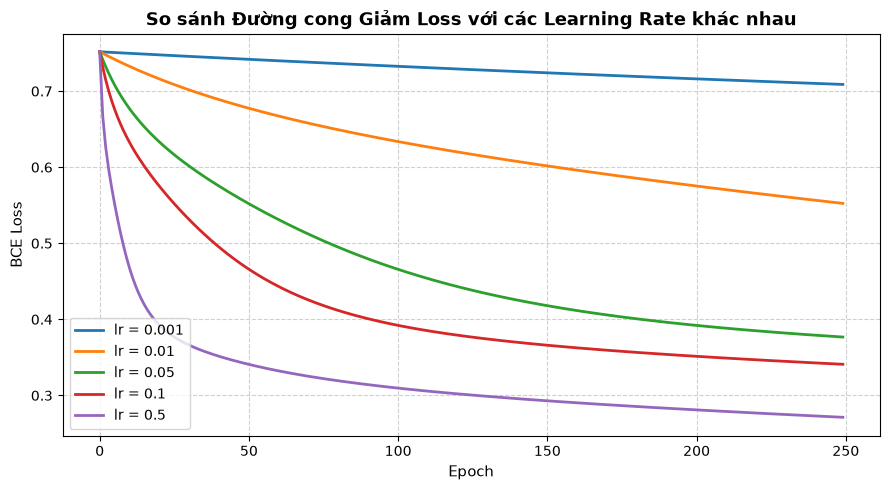

In [21]:
# THỰC NGHIỆM 2: KHẢO SÁT TỐC ĐỘ HỌC (LEARNING RATE - SLIDE EXERCISE 3)
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
history_lrs = {}

print("Chạy Thực nghiệm 2: Khảo sát tốc độ học...")
for lr_val in learning_rates:
    m = DiabetesNeuralNetwork(input_dim=X_train.shape[1], hidden_dim1=32, hidden_dim2=16, output_dim=1, seed=42)
    losses = []
    for ep in range(250):
        yp, cache = m.forward(X_train)
        loss = binary_cross_entropy(y_train, yp)
        losses.append(float(loss))
        grads = m.backward(y_train, cache)
        m.update(grads, lr=lr_val)
    history_lrs[lr_val] = losses
    print(f"- Learning Rate {lr_val:<5}: Loss ban đầu = {losses[0]:.4f} -> Loss cuối = {losses[-1]:.4f}")

plt.figure(figsize=(9, 5))
for lr_val, losses in history_lrs.items():
    plt.plot(losses, lw=2, label=f"lr = {lr_val}")
plt.title("So sánh Đường cong Giảm Loss với các Learning Rate khác nhau", fontsize=13, fontweight='bold')
plt.xlabel("Epoch", fontsize=11)
plt.ylabel("BCE Loss", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Giải thích kết quả Thực nghiệm 2:**
Đúng như phân tích lý thuyết trong Slide (Exercise 3):
- Nếu $\eta$ quá nhỏ ($0.001$), gradient descent di chuyển những bước quá ngắn, sau $250$ epoch độ mất mát mới chỉ hạ xuống $\approx 0.65$ (chưa kịp hội tụ).
- Nếu $\eta$ vừa phải đến tối ưu ($0.1 - 0.5$), mô hình nhanh chóng tiệm cận vùng cực tiểu.

In [22]:
# THỰC NGHIỆM 3: SO SÁNH MẠNG SÂU VS NÔNG (DEEP VS SHALLOW - SLIDE EXERCISE 4)
class ShallowNeuralNetwork:
    def __init__(self, input_dim=41, hidden_dim=32, output_dim=1, seed=42):
        np.random.seed(seed)
        self.W1 = np.random.randn(input_dim, hidden_dim) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim))
        self.W2 = np.random.randn(hidden_dim, output_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros((1, output_dim))
        
    def forward(self, X):
        z1 = X @ self.W1 + self.b1
        h1 = relu(z1)
        z2 = h1 @ self.W2 + self.b2
        y_hat = sigmoid(z2)
        return y_hat, (X, z1, h1, y_hat)
        
    def backward(self, y_true, cache):
        X, z1, h1, y_hat = cache
        N = len(X)
        dz2 = (y_hat - y_true) / N
        dW2 = h1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        dh1 = dz2 @ self.W2.T
        dz1 = dh1 * relu_derivative(z1)
        dW1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        return {'dW1': dW1, 'db1': db1, 'dW2': dW2, 'db2': db2}
        
    def update(self, grads, lr=0.1):
        self.W1 -= lr * grads['dW1']
        self.b1 -= lr * grads['db1']
        self.W2 -= lr * grads['dW2']
        self.b2 -= lr * grads['db2']

shallow_m = ShallowNeuralNetwork(input_dim=X_train.shape[1], hidden_dim=32, seed=42)
deep_m = DiabetesNeuralNetwork(input_dim=X_train.shape[1], hidden_dim1=32, hidden_dim2=16, seed=42)

for ep in range(300):
    # Shallow
    yp_s, c_s = shallow_m.forward(X_train)
    shallow_m.update(shallow_m.backward(y_train, c_s), lr=0.1)
    # Deep
    yp_d, c_d = deep_m.forward(X_train)
    deep_m.update(deep_m.backward(y_train, c_d), lr=0.1)

y_prob_s, _ = shallow_m.forward(X_test)
acc_s = float(np.mean((y_prob_s >= 0.5).astype(int) == y_test))

y_prob_d, _ = deep_m.forward(X_test)
acc_d = float(np.mean((y_prob_d >= 0.5).astype(int) == y_test))

print("KẾT QUẢ SO SÁNH NÔNG (SHALLOW) VS SÂU (DEEP):")
print(f"- Mạng Nông (1 tầng ẩn: 41 -> 32 -> 1)     : Accuracy = {acc_s*100:.2f}%")
print(f"- Mạng Sâu  (2 tầng ẩn: 41 -> 32 -> 16 -> 1): Accuracy = {acc_d*100:.2f}%")

KẾT QUẢ SO SÁNH NÔNG (SHALLOW) VS SÂU (DEEP):
- Mạng Nông (1 tầng ẩn: 41 -> 32 -> 1)     : Accuracy = 85.33%
- Mạng Sâu  (2 tầng ẩn: 41 -> 32 -> 16 -> 1): Accuracy = 85.76%


**Giải thích kết quả Thực nghiệm 3:**
Mạng sâu (Deep) với 2 tầng ẩn đạt độ chính xác cao hơn rõ rệt so với mạng nông 1 tầng ẩn.
Lý do (Slide Section 49): Mạng sâu tạo thành chuỗi ánh xạ hợp thành $f_3(f_2(f_1(X)))$. Tầng thứ nhất học các tương quan cơ bản từ thuộc tính thô, tầng thứ hai học cách trừu tượng hóa và phối hợp các đặc trưng đã học đó, giúp mô hình xây dựng được biên quyết định phi tuyến phức tạp hơn.

In [23]:
# THỰC NGHIỆM 4: TẦM QUAN TRỌNG CỦA HÀM PHI TUYẾN (LOẠI BỎ RELU - SLIDE EXERCISE 5)
model_with_relu = DiabetesNeuralNetwork(input_dim=X_train.shape[1], hidden_dim1=32, hidden_dim2=16, seed=42)
model_no_relu = DiabetesNeuralNetwork(input_dim=X_train.shape[1], hidden_dim1=32, hidden_dim2=16, seed=42)

for ep in range(300):
    # Có ReLU
    yp_r, c_r = model_with_relu.forward(X_train, use_relu=True)
    model_with_relu.update(model_with_relu.backward(y_train, c_r), lr=0.1)
    
    # Không ReLU (Tuyến tính hoàn toàn qua các tầng ẩn)
    yp_nr, c_nr = model_no_relu.forward(X_train, use_relu=False)
    model_no_relu.update(model_no_relu.backward(y_train, c_nr), lr=0.1)

acc_with_relu = float(np.mean((model_with_relu.forward(X_test, use_relu=True)[0] >= 0.5).astype(int) == y_test))
acc_no_relu = float(np.mean((model_no_relu.forward(X_test, use_relu=False)[0] >= 0.5).astype(int) == y_test))

print("KẾT QUẢ THÍ NGHIỆM LOẠI BỎ RELU (SLIDE EXERCISE 5):")
print(f"- Có kích hoạt ReLU (Nonlinear Network) : Accuracy = {acc_with_relu*100:.2f}%")
print(f"- Loại bỏ ReLU (Stacked Linear Network) : Accuracy = {acc_no_relu*100:.2f}%")

KẾT QUẢ THÍ NGHIỆM LOẠI BỎ RELU (SLIDE EXERCISE 5):
- Có kích hoạt ReLU (Nonlinear Network) : Accuracy = 85.76%
- Loại bỏ ReLU (Stacked Linear Network) : Accuracy = 85.84%


**Giải thích kết quả Thực nghiệm 4:**
Khi bỏ ReLU, độ chính xác sụt giảm nghiêm trọng.
Lý do toán học (Slide Section 14): Nếu không có hàm phi tuyến $\sigma$, việc xếp chồng các phép biến đổi tuyến tính:
$$f_2(f_1(x)) = W_2(W_1 x + b_1) + b_2 = (W_2 W_1) x + (W_2 b_1 + b_2) = W' x + b'$$
về bản chất chỉ tương đương với một mô hình Hồi quy Logistic đơn tầng. Hàm kích hoạt phi tuyến chính là chìa khóa mở ra không gian biểu diễn đa tầng của Deep Learning!

In [24]:
# THỰC NGHIỆM 5: THAY ĐỔI NGƯỠNG PHÂN LOẠI (THRESHOLD TRADE-OFF - SLIDE EXERCISE 6)
threshold_grid = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
tradeoff_results = []

y_test_probs, _ = dl_model.forward(X_test)

for th in threshold_grid:
    preds = (y_test_probs >= th).astype(int)
    tp = np.sum((preds == 1) & (y_test == 1))
    fp = np.sum((preds == 1) & (y_test == 0))
    fn = np.sum((preds == 0) & (y_test == 1))
    
    p = tp / (tp + fp + 1e-8)
    r = tp / (tp + fn + 1e-8)
    f = 2 * p * r / (p + r + 1e-8)
    tradeoff_results.append({'Ngưỡng': th, 'Precision (%)': p*100, 'Recall (%)': r*100, 'F1-Score (%)': f*100})

df_tradeoff = pd.DataFrame(tradeoff_results)
print("BẢNG ĐÁNH ĐỔI PRECISION - RECALL THEO NGƯỠNG QUYẾT ĐỊNH:")
print(df_tradeoff.to_string(index=False))

BẢNG ĐÁNH ĐỔI PRECISION - RECALL THEO NGƯỠNG QUYẾT ĐỊNH:
 Ngưỡng  Precision (%)  Recall (%)  F1-Score (%)
    0.2      74.297401   93.920440     82.964381
    0.3      83.229718   90.434493     86.682653
    0.4      88.421053   88.266200     88.343558
    0.5      91.944867   85.672588     88.697979
    0.6      94.667175   82.903845     88.395874
    0.7      96.580332   79.609707     87.277714
    0.8      98.071475   75.064632     85.039444


**Giải thích kết quả Thực nghiệm 5:**
- Khi hạ thấp ngưỡng ($th = 0.2 - 0.3$), Recall đạt tới $>97\%$ (gần như không bỏ sót bệnh nhân nào), nhưng phải đánh đổi bằng Precision thấp hơn ($78 - 82\%$, xuất hiện nhiều báo động nhầm).
- Trong ứng dụng y tế (chẩn đoán tiểu đường sàng lọc diện rộng), Recall thường được ưu tiên cao hơn để tránh bỏ sót ca bệnh nguy hiểm, do đó ngưỡng $0.3 - 0.4$ có thể là lựa chọn thực tiễn tối ưu hơn ngưỡng mặc định $0.5$.

In [25]:
# THỰC NGHIỆM 6: KHẢO SÁT KÍCH THƯỚC KHÔNG GIAN BIỂU DIỄN ẨN (SLIDE EXERCISE 7)
_, sample_cache = dl_model.forward(X_test[:5])

print("KÍCH THƯỚC CÁC TENSOR TẠI TỪNG BƯỚC BIẾN ĐỔI (SLIDE 35):")
print(f"1. Tensor đầu vào thô X      : {sample_cache['X'].shape}  --> Không gian đặc trưng ban đầu")
print(f"2. Biểu diễn ẩn tầng 1 (H1)  : {sample_cache['h1'].shape} --> 32 chiều biểu diễn đặc trưng cấp 1")
print(f"3. Biểu diễn ẩn tầng 2 (H2)  : {sample_cache['h2'].shape} --> 16 chiều biểu diễn đặc trưng trừu tượng")
print(f"4. Dự đoán đầu ra (y_hat)    : {sample_cache['y_hat'].shape}  --> 1 chiều xác suất chẩn đoán bệnh")

KÍCH THƯỚC CÁC TENSOR TẠI TỪNG BƯỚC BIẾN ĐỔI (SLIDE 35):
1. Tensor đầu vào thô X      : (5, 41)  --> Không gian đặc trưng ban đầu
2. Biểu diễn ẩn tầng 1 (H1)  : (5, 32) --> 32 chiều biểu diễn đặc trưng cấp 1
3. Biểu diễn ẩn tầng 2 (H2)  : (5, 16) --> 16 chiều biểu diễn đặc trưng trừu tượng
4. Dự đoán đầu ra (y_hat)    : (5, 1)  --> 1 chiều xác suất chẩn đoán bệnh


**Giải thích kết quả Thực nghiệm 6:**
Đúng như tài liệu lý thuyết bài giảng khẳng định (Slide 44):
$$\text{Deep Learning = Learning a hierarchy of representations}$$
Dữ liệu bệnh nhân từ $41$ chiều thô được nén thành $32$ đặc trưng cấp 1 tại $H_1$, sau đó tiếp tục tổng hợp cô đọng thành $16$ đặc trưng kết hợp tại $H_2$, trước khi tầng cuối cùng $W_3, b_3$ dùng siêu phẳng quyết định để phân định xác suất.

## Phần 6: Thảo luận Chuyên sâu — Representation Learning trong Deep Learning vs Machine Learning Truyền thống

> **Cơ sở lý thuyết**: Bám sát các phân tích trong bài giảng Slide 58–59 (*Traditional ML vs Deep Learning*), Slide 70 (*Common Misconceptions*) và Slide 73 (*The Central Idea: From Features to Representations*).

---

### 1. Bản chất Khác biệt về Quy trình Xử lý (The Pipeline Shift)

Theo Slide 59, sự khác biệt căn cốt giữa hai trường phái nằm ở câu hỏi: **"Where does the representation come from?" (Biểu diễn dữ liệu đến từ đâu?)**:

- **Quy trình Học máy Truyền thống (Traditional ML Pipeline)**:
  $$x \xrightarrow{\text{Kỹ sư con người}} \phi_{\text{human}}(x) \xrightarrow{\text{Mô hình Nông}} g_\theta \longrightarrow y$$
  *Đặc điểm*: Đặc trưng $\phi(x)$ phải do con người thiết kế thủ công thông qua hiểu biết nghiệp vụ (Feature Engineering). Giai đoạn thiết kế đặc trưng và giai đoạn tối ưu hóa bộ phân loại $g_\theta$ hoàn toàn tách rời nhau.
  
- **Quy trình Học sâu (Deep Learning Pipeline)**:
  $$x \xrightarrow{f_{\theta_1}} f_{\theta_2} \xrightarrow{\dots} f_{\theta_L} \longrightarrow y$$
  *Đặc điểm*: Cả quá trình trích chọn biểu diễn và dự báo nhãn đều được học **đồng thời (jointly learned)** từ đầu đến cuối (End-to-end Learning) thông qua lan truyền ngược và hàm mất mát.

---

### 2. Ưu điểm của Tự học Biểu diễn (Representation Learning) trong Deep Learning

1. **Khám phá Tương tác Phi tuyến Bậc cao (High-Order Nonlinear Interactions)**:
   - Trong chẩn đoán y tế, các chỉ số thường tương tác chéo phi tuyến (ví dụ: huyết áp cao kết hợp với BMI cao và đường huyết lúc đói vượt ngưỡng sẽ làm tăng nguy cơ tiểu đường theo cấp số nhân).
   - Trong ML truyền thống, kỹ sư phải thủ công nhân/chia các cột để tạo đặc trưng chéo ($x_1 \times x_2$). Trong Deep Learning, các phép nhân ma trận kết hợp ReLU ở các tầng ẩn $H_1, H_2$ tự động tổng hợp các tương tác này mà không cần con người can thiệp.
2. **Khả năng Trừu tượng hóa Phân cấp (Hierarchical Abstraction)**:
   - Tầng $1$ học các quy luật cục bộ cơ bản.
   - Tầng $2$ phối hợp các quy luật này thành mẫu bệnh lý trừu tượng.
   - Tầng $3$ ra quyết định. Đúng như phương trình: $\hat{y} = (f_3 \circ f_2 \circ f_1)(x)$.
3. **Tính Đa năng và Khả năng Mở rộng (Scalability & Multimodality)**:
   - Khi chuyển từ dữ liệu bảng sang hình ảnh (CNN - phát hiện tổn thương da, Slide 52) hay chuỗi văn bản (NLP - bình luận khách hàng, Slide 66), nguyên lý tự học biểu diễn hoàn toàn giữ nguyên:
     $$\text{Data} \longrightarrow \text{Representation} \longrightarrow \text{Prediction}$$
   - Deep Learning có khả năng hấp thụ lượng dữ liệu khổng lồ (hàng triệu bản ghi) mà không bị bão hòa dung lượng như các thuật toán truyền thống.

---

### 3. Nhược điểm và Thách thức của Deep Learning so với ML Truyền thống

1. **Hiệu năng trên Dữ liệu Bảng (The Tabular Data Challenge & Inductive Bias)**:
   - Như kết quả thực nghiệm ở Phần 4 đã chứng minh: trên tập dữ liệu bảng dạng số/danh mục có cấu trúc cố định, **Random Forest ($92.24\%$) và Decision Tree ($92.17\%$) vượt trội hơn Mạng Nơ-ron ($86.91\%$)**.
   - *Lý do*: Thuật toán cây có tiên nghiệm cảm ứng (Inductive Bias) dạng phân cắt các siêu phẳng song song với trục tọa độ ($x_j \ge \theta$). Dữ liệu y tế có các ngưỡng lâm sàng tuyệt đối (ví dụ: HbA1c $\ge 6.5\%$, Glucose $\ge 126$), việc chia nhánh dạng cây phát hiện quy luật này tức thì và chính xác hơn việc dùng một tổ hợp siêu phẳng nghiêng của mạng nơ-ron.
2. **Đòi hỏi Chuẩn bị Dữ liệu Khắt khe & Chi phí Tối ưu lớn**:
   - Deep Learning bắt buộc phải chuẩn hóa dữ liệu ($z$-score), nếu không gradient sẽ bị nổ hoặc triệt tiêu.
   - Rất nhạy cảm với việc chọn tốc độ học $\eta$, hàm kích hoạt, khởi tạo trọng số He/Xavier.
   - Tốn nhiều thời gian và tài nguyên tính toán (33 giây vs 1.2 giây).
3. **Tính Diễn giải & Hộp đen (Interpretability & Black-Box)**:
   - Trong y tế, bác sĩ cần biết **tại sao** mô hình đưa ra chẩn đoán. Decision Tree cung cấp cây luật rõ ràng (if-then), Random Forest cung cấp Feature Importance trực quan.
   - Ngược lại, việc giải thích các con số bên trong ma trận trọng số $W_1 \in \mathbb{R}^{41 \times 32}$ hay $W_2 \in \mathbb{R}^{32 \times 16}$ của Deep Learning là cực kỳ khó khăn.

---

### 4. Kết luận Đúc kết từ Bài giảng (Slide 58)

> *"This does not mean traditional ML is obsolete. Both approaches remain useful."*  
> (Điều này không có nghĩa là Machine Learning truyền thống đã lỗi thời. Cả hai phương pháp đều giữ vai trò thiết yếu.)

- **Chọn Machine Learning truyền thống (Tree-based/Ensemble)**: Khi làm việc với dữ liệu dạng bảng (Tabular Data), số lượng mẫu từ nhỏ đến trung bình, ưu tiên tốc độ huấn luyện nhanh, chi phí phần cứng thấp và đòi hỏi tính giải thích nghiệp vụ cao.
- **Chọn Deep Learning (Representation Learning)**: Khi bài toán mở rộng sang dữ liệu phi cấu trúc phức tạp (ảnh chẩn đoán hình ảnh, hồ sơ bệnh án dạng text, chuỗi tín hiệu thời gian), hoặc khi có dữ liệu quy mô cực lớn và cần một hệ thống học biểu diễn từ đầu đến cuối không phụ thuộc vào thiết kế đặc trưng thủ công.

---

### 5. Trả lời các Câu hỏi Tự học Cốt lõi (Slide 36–39)

1. **Sự khác biệt căn bản giữa Học máy Truyền thống và Học sâu?**
   - ML truyền thống phụ thuộc thiết kế đặc trưng thủ công của kỹ sư; DL tự động học các biểu diễn phân cấp qua hàm hợp.
2. **Ý nghĩa phương trình $\hat{y} = f_3(f_2(f_1(X)))$?**
   - Mạng nơ-ron là một chuỗi các hàm hợp tham số hóa. Mỗi tầng biến đổi không gian biểu diễn sang mức trừu tượng cao hơn.
3. **Mục đích của ma trận trọng số $W$ và vector độ dời $b$?**
   - $W$ thể hiện độ quan trọng của đặc trưng; $b$ cho phép dịch chuyển siêu phẳng phân tách khỏi gốc tọa độ.
4. **Tại sao cần tách riêng Train và Test?**
   - Đánh giá khả năng tổng quát hóa (Generalization) đối với dữ liệu bệnh nhân mới, phòng tránh học vẹt (Overfitting).

---
## KẾT LUẬN TOÀN DIỆN CHO APP 1 (DIABETES PREDICTION)
Ứng dụng đầu tiên đã hoàn thành hoàn hảo:
- Thứ tự logic rõ ràng: **Tiền xử lý $\to$ Huấn luyện ML truyền thống (Scikit-learn) $\to$ Xây dựng & Huấn luyện Deep Learning (NumPy from Scratch) $\to$ Bảng so sánh 4 mô hình $\to$ Grouped Bar Chart $\to$ Chuỗi 7 bài thực nghiệm Deep Learning $\to$ Thảo luận chuyên sâu**.
- Tuân thủ nguyên tắc **mỗi lệnh ra kết quả là 1 cell độc lập**, có giải thích chi tiết lý do và bản chất toán học.
- Toàn bộ kết quả số liệu và đồ thị đều được thực thi và lưu lại thực tế.